# NDMC Conductivity MPC Notebook

This notebook is a reproducible NDMC conductivity MPC experiment.

It does four things:
- rerun one NDMC closed-loop case built on `build_tracking_mpc(...)`;
- read the saved CSV outputs;
- visualize the closed-loop behavior in a publication-style format;
- inspect timing tables when benchmarking is needed.


In [1]:
using Pkg

bootstrap_path = joinpath(pwd(), "notebooks", "bootstrap_examples_notebook_env.jl")
if !isfile(bootstrap_path)
    bootstrap_path = joinpath(pwd(), "bootstrap_examples_notebook_env.jl")
end
include(bootstrap_path)

# Always instantiate here so a fresh machine installs the notebook dependencies
# before the first `using CSV, DataFrames, Plots` call.
env_info = prepare_examples_notebook_env(dirname(bootstrap_path); instantiate=true, io=devnull)
repo_root = env_info.repo_root
examples_env = env_info.examples_env
generated_dir = env_info.generated_dir
ndmc_module_path = env_info.ndmc_module_path

using EOptInterface
using CSV, DataFrames, Plots
using Statistics

include(ndmc_module_path)
using .NDMCExample

style_path = env_info.style_path
include(style_path)
apply_eoi_publication_style!()


## Re-run the NDMC Example

This cell runs the same NDMC case used by the script version.
The plant equations, MPC setup, and closed-loop simulation are kept in `examples/ndmc_case.jl` so the experiment can be read directly.

By default it enables the NDMC-specific detailed live log so each MPC trigger prints one status line in the cell output.
You can also enable the package's generic `show_status` line from the rerun cell below if you want both views at once.

The default case uses:
- `dt = 20 s`;
- `P = 20`;
- `M = 3`;
- one low-zone influent shock from `2100 s` to `2250 s`;
- one shared `Q_air` manipulated variable.

The figures below use the same disturbance window as the paper-style benchmark discussion.


In [2]:
rerun_closed_loop = false
rerun_show_detailed_status = true
rerun_show_generic_status = false

rerun_result = nothing

if rerun_closed_loop
    rerun_cfg = NDMCMPCConfig(
        show_detailed_status = rerun_show_detailed_status,
        show_generic_status = rerun_show_generic_status,
    )
    rerun_result = run_ndmc_case(
        rerun_cfg;
        save_outputs = true,
        announce_outputs = true,
        output_dir = generated_dir,
    )
end


## Time Profile of NDMC MPC
This optional cell reruns the NDMC case and records wall-clock timing for the main workflow: model build, MPC setup, online solves, callbacks, and simulation. The table construction lives in `examples/NDMCExample.jl`; the notebook only calls the report function and displays the results.


In [ ]:
profiled_rerun_closed_loop = true
profiled_show_detailed_status = false
profiled_show_generic_status = false

if profiled_rerun_closed_loop
    profile_cfg = NDMCMPCConfig(
        show_detailed_status = profiled_show_detailed_status,
        show_generic_status = profiled_show_generic_status,
    )
    profile_report = run_ndmc_workflow_timing_report(
        profile_cfg;
        output_dir = generated_dir,
        save_outputs = true,
        announce_outputs = true,
    )
else
    error("Set profiled_rerun_closed_loop = true so the notebook can regenerate all timing modes together.")
end

profile_summary = profile_report.profile_summary
profile_steps = profile_report.profile_steps
profile_env = profile_report.profile_env

summary_view = profile_report.summary_view
runtime_split_view = profile_report.runtime_split_view
callback_breakdown_view = profile_report.callback_breakdown_view
comparison_view = profile_report.comparison_view
budget_view = profile_report.budget_view
online_step_stats = profile_report.online_step_stats
env_view = profile_report.env_view

display(summary_view)
display(runtime_split_view)
display(callback_breakdown_view)
display(comparison_view)
display(budget_view)
display(online_step_stats)
display(env_view)

profile_report.profile_dashboard


## Isolated BenchmarkTools Timing for NDMC
This optional cell times individual hot stages that can be separated from the closed-loop simulation. It calls the NDMC example helper, then displays the readable tables returned by that helper.


In [ ]:
btime_snapshot_time = ndmc_default_btime_snapshot_time(NDMCMPCConfig())
btime_samples = 10
btime_evals = 1
btime_seconds = 2.0

btime_cfg = NDMCMPCConfig(
    show_detailed_status = false,
    show_generic_status = false,
)

workflow_report_for_workbook = isdefined(Main, :profile_report) ? profile_report : nothing
btime_report = run_ndmc_isolated_btime_report(
    btime_cfg;
    snapshot_time = btime_snapshot_time,
    samples = btime_samples,
    evals = btime_evals,
    seconds = btime_seconds,
    output_dir = generated_dir,
    workflow_report = workflow_report_for_workbook,
    save_outputs = true,
    save_workbook = true,
    announce_outputs = true,
)

btime_summary = btime_report.summary
btime_snapshot = btime_report.snapshot

display(btime_summary)
display(btime_snapshot)


## Whole-Workflow BenchmarkTools Timing for NDMC

This cell treats the entire NDMC run as one warm BenchmarkTools target. It includes model/controller build, the initial control update, the closed-loop simulation, and the callback step that writes the computed `Q_air` back into the plant state. The benchmark code lives in `examples/NDMCExample.jl`; this cell only calls it and displays the summary.


In [ ]:
whole_workflow_samples = 3
whole_workflow_evals = 1
whole_workflow_seconds = 30.0

whole_workflow_cfg = NDMCMPCConfig(
    show_detailed_status = false,
    show_generic_status = false,
)

whole_workflow_summary = run_ndmc_whole_workflow_btime(
    whole_workflow_cfg;
    samples = whole_workflow_samples,
    evals = whole_workflow_evals,
    seconds = whole_workflow_seconds,
)

display(whole_workflow_summary)
println("Whole-workflow NDMC BenchmarkTools timing displayed above.")


In [6]:
closed_loop_path = joinpath(generated_dir, "ndmc_conductivity_eopt_closed_loop.csv")
applied_path = joinpath(generated_dir, "ndmc_conductivity_eopt_applied_control.csv")
name_map_path = joinpath(generated_dir, "ndmc_conductivity_eopt_name_map.csv")

isfile(closed_loop_path) || error("Missing $(closed_loop_path). Run the example cell first.")
isfile(applied_path) || error("Missing $(applied_path). Run the example cell first.")
isfile(name_map_path) || error("Missing $(name_map_path). Run the example cell first.")

closed_loop = CSV.read(closed_loop_path, DataFrame)
applied = CSV.read(applied_path, DataFrame)
name_map = CSV.read(name_map_path, DataFrame)

first(closed_loop, 5)

Row,time,C1,C2,C3,Cmix,cO,Q_air
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,280.0,280.0,280.0,280.0,0.0,439.221
2,10.0,280.113,280.113,280.113,280.113,0.107874,439.221
3,20.0,280.116,280.116,280.116,280.116,0.189285,300.46
4,30.0,280.076,280.076,280.076,280.076,0.219269,300.46
5,40.0,280.02,280.02,280.02,280.019,0.244632,48.1608


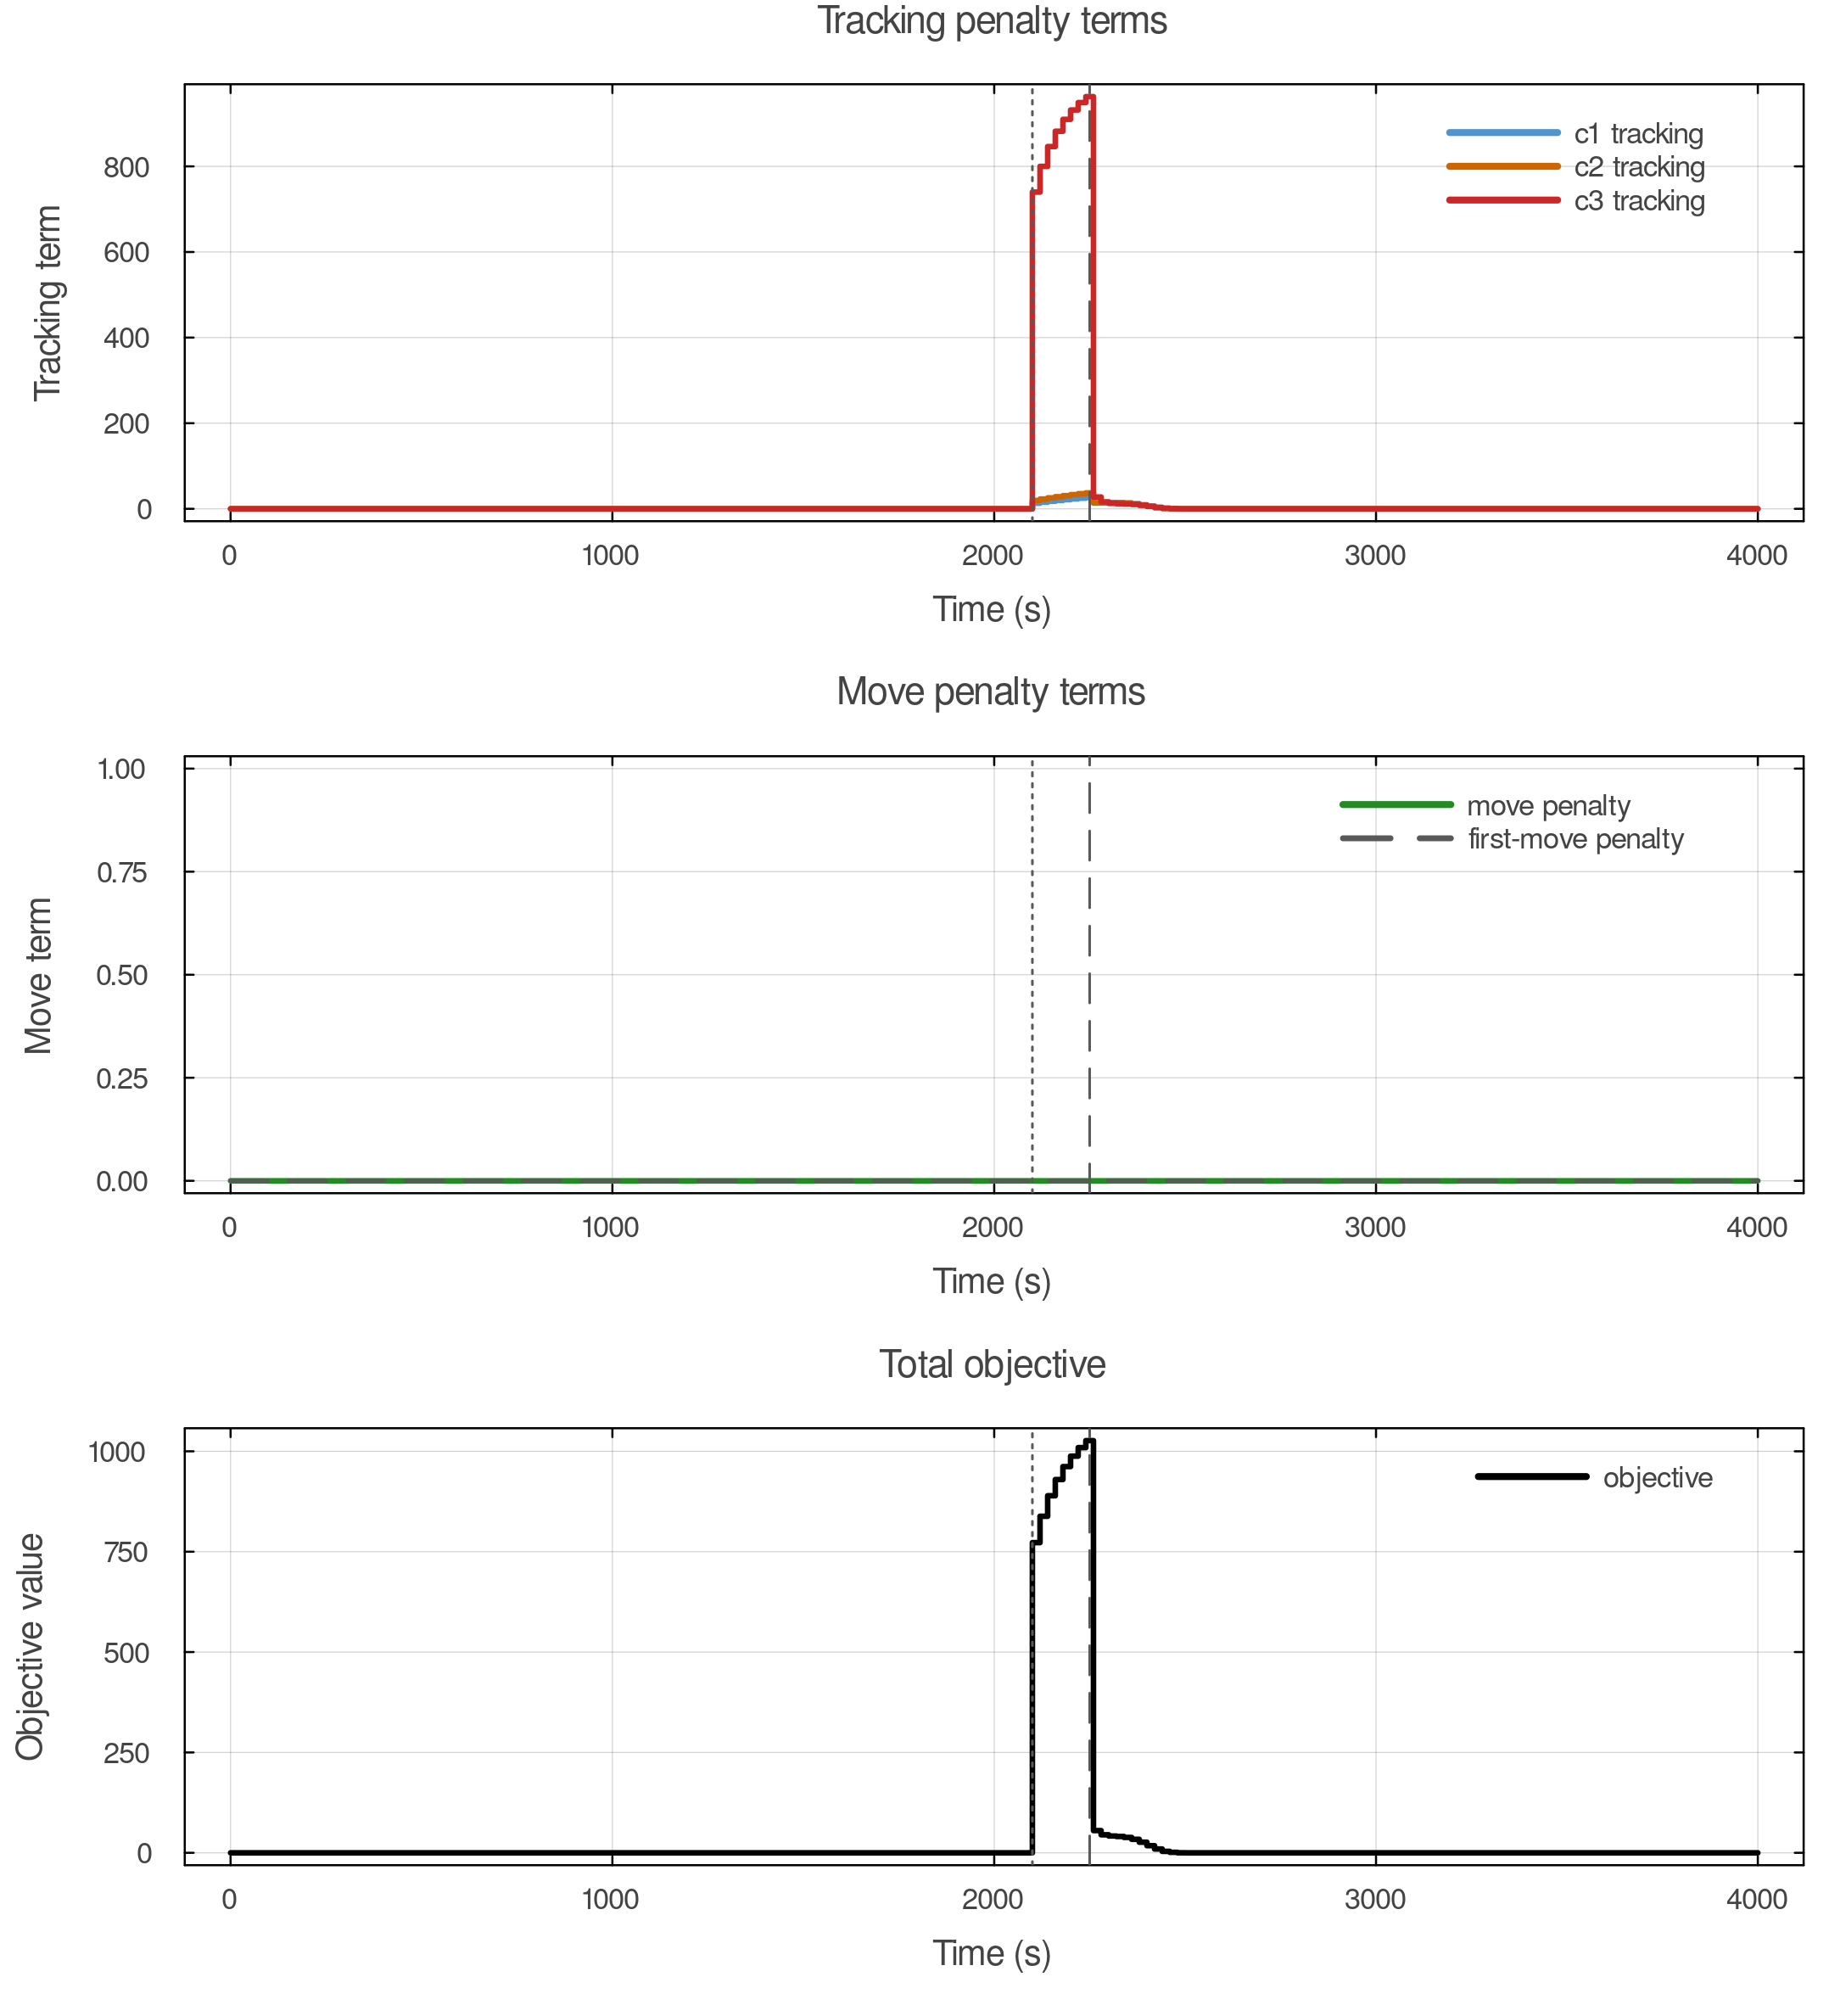

In [7]:
ndmc_plot_penalty_terms(applied; disturbance_window = NDMC_NOTEBOOK_PLOT_CONFIG.disturbance_window)


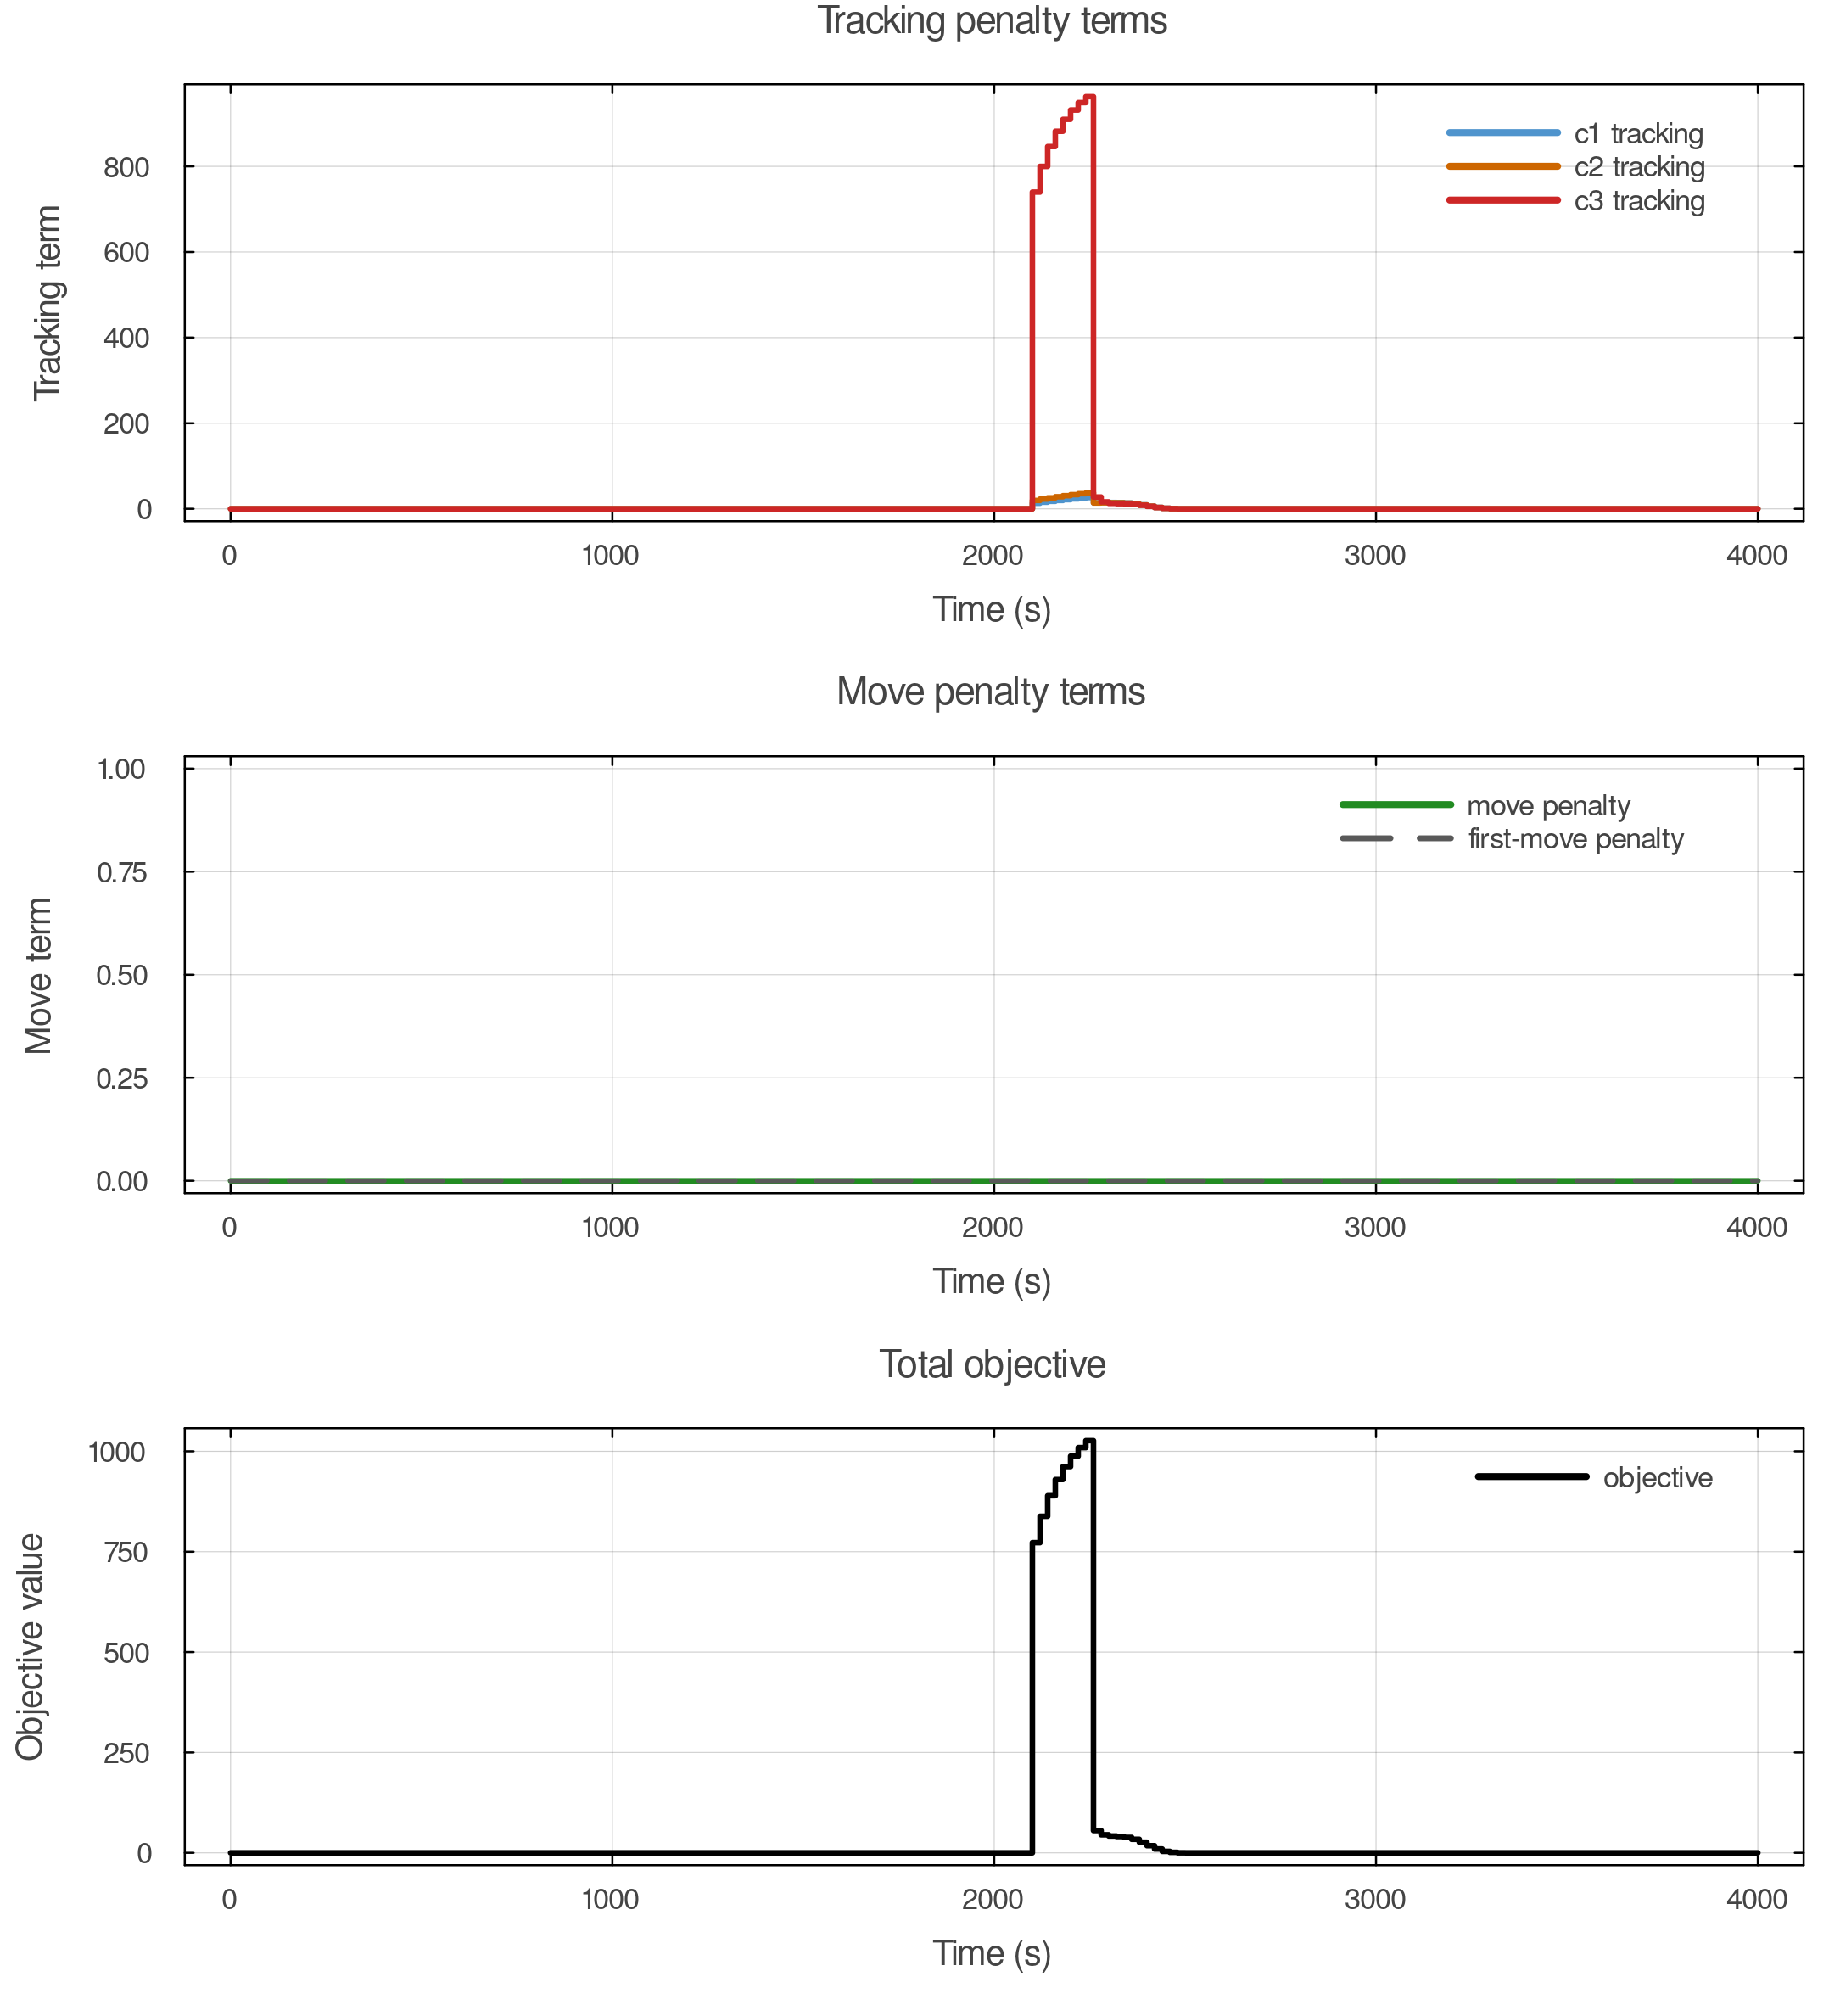

In [8]:
ndmc_plot_penalty_terms(applied)


## Names Used by the NDMC Example

This example does not hand-build JuMP names.
Instead, it passes `base_name` through `MPCControlSpec` and `MPCOutputSpec`, then reuses the naming table stored with the MPC problem.

That matters for two reasons:
- the example stays cleaner;
- downstream code can still find the right trajectory by a human-readable name.


In [9]:
name_map


Row,category,symbol,base_name
,String7,String7,String7
1,control,Q_air,Q_air
2,output,C1(t),C1
3,output,C2(t),C2
4,output,C3(t),C3


## Compare with the Legacy DMC Baseline

This section compares the current EOptInterface MPC result with the legacy DMC implementation in `examples/MPC_NDMC.jl`.

It keeps the same low-zone shock benchmark and uses the same paper-style disturbance window for the focused comparison plots.
The comparison data are stored in `examples/generated`, and the cell below can refresh them if the current MPC result or the legacy script changes.


In [10]:
rerun_legacy_comparison = false

legacy_script = joinpath(repo_root, "examples", "MPC_NDMC.jl")
legacy_generator = joinpath(repo_root, "examples", "generate_ndmc_legacy_comparison.jl")
legacy_summary_path = joinpath(generated_dir, "ndmc_vs_legacy_summary_10s.csv")
legacy_path = joinpath(generated_dir, "legacy_mpc_ndmc_closed_loop_10s.csv")
comparison_path = joinpath(generated_dir, "ndmc_vs_legacy_comparison_10s.csv")

comparison_outputs = [legacy_summary_path, legacy_path, comparison_path]
comparison_inputs = [closed_loop_path, legacy_script, legacy_generator]

comparison_outputs_ready = all(isfile, comparison_outputs)
comparison_outputs_stale = !comparison_outputs_ready || maximum(stat(path).mtime for path in comparison_inputs) > minimum(stat(path).mtime for path in comparison_outputs)
rerun_legacy_comparison = rerun_legacy_comparison || comparison_outputs_stale

if rerun_legacy_comparison
    cmd = `$(Base.julia_cmd()) --project=$(examples_env) $legacy_generator $closed_loop_path $legacy_path $comparison_path $legacy_summary_path`
    run(cmd)
end



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Process(`/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/bin/julia -C native -J/Users/xupengfei/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/lib/julia/sys.dylib -g1 --color=yes '--project=/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generate_ndmc_legacy_comparison.jl' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_conductivity_eopt_closed_loop.csv' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/legacy_mpc_ndmc_closed_loop_10s.csv' '/Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/generated/ndmc_vs_legacy_comparison_10s.csv' '/Vo

In [11]:
legacy_summary = CSV.read(legacy_summary_path, DataFrame)
legacy_summary


Row,metric,value
,String31,Float64
1,RMSE diff C1,0.576218
2,RMSE diff C2,0.576223
3,RMSE diff C3,0.576215
4,RMSE diff Cmix,0.576272
5,RMSE diff cO,0.251048
6,RMSE diff Q,143.956
7,Max abs diff C1,3.18495
8,Max abs diff C2,3.18498
9,Max abs diff C3,3.18497


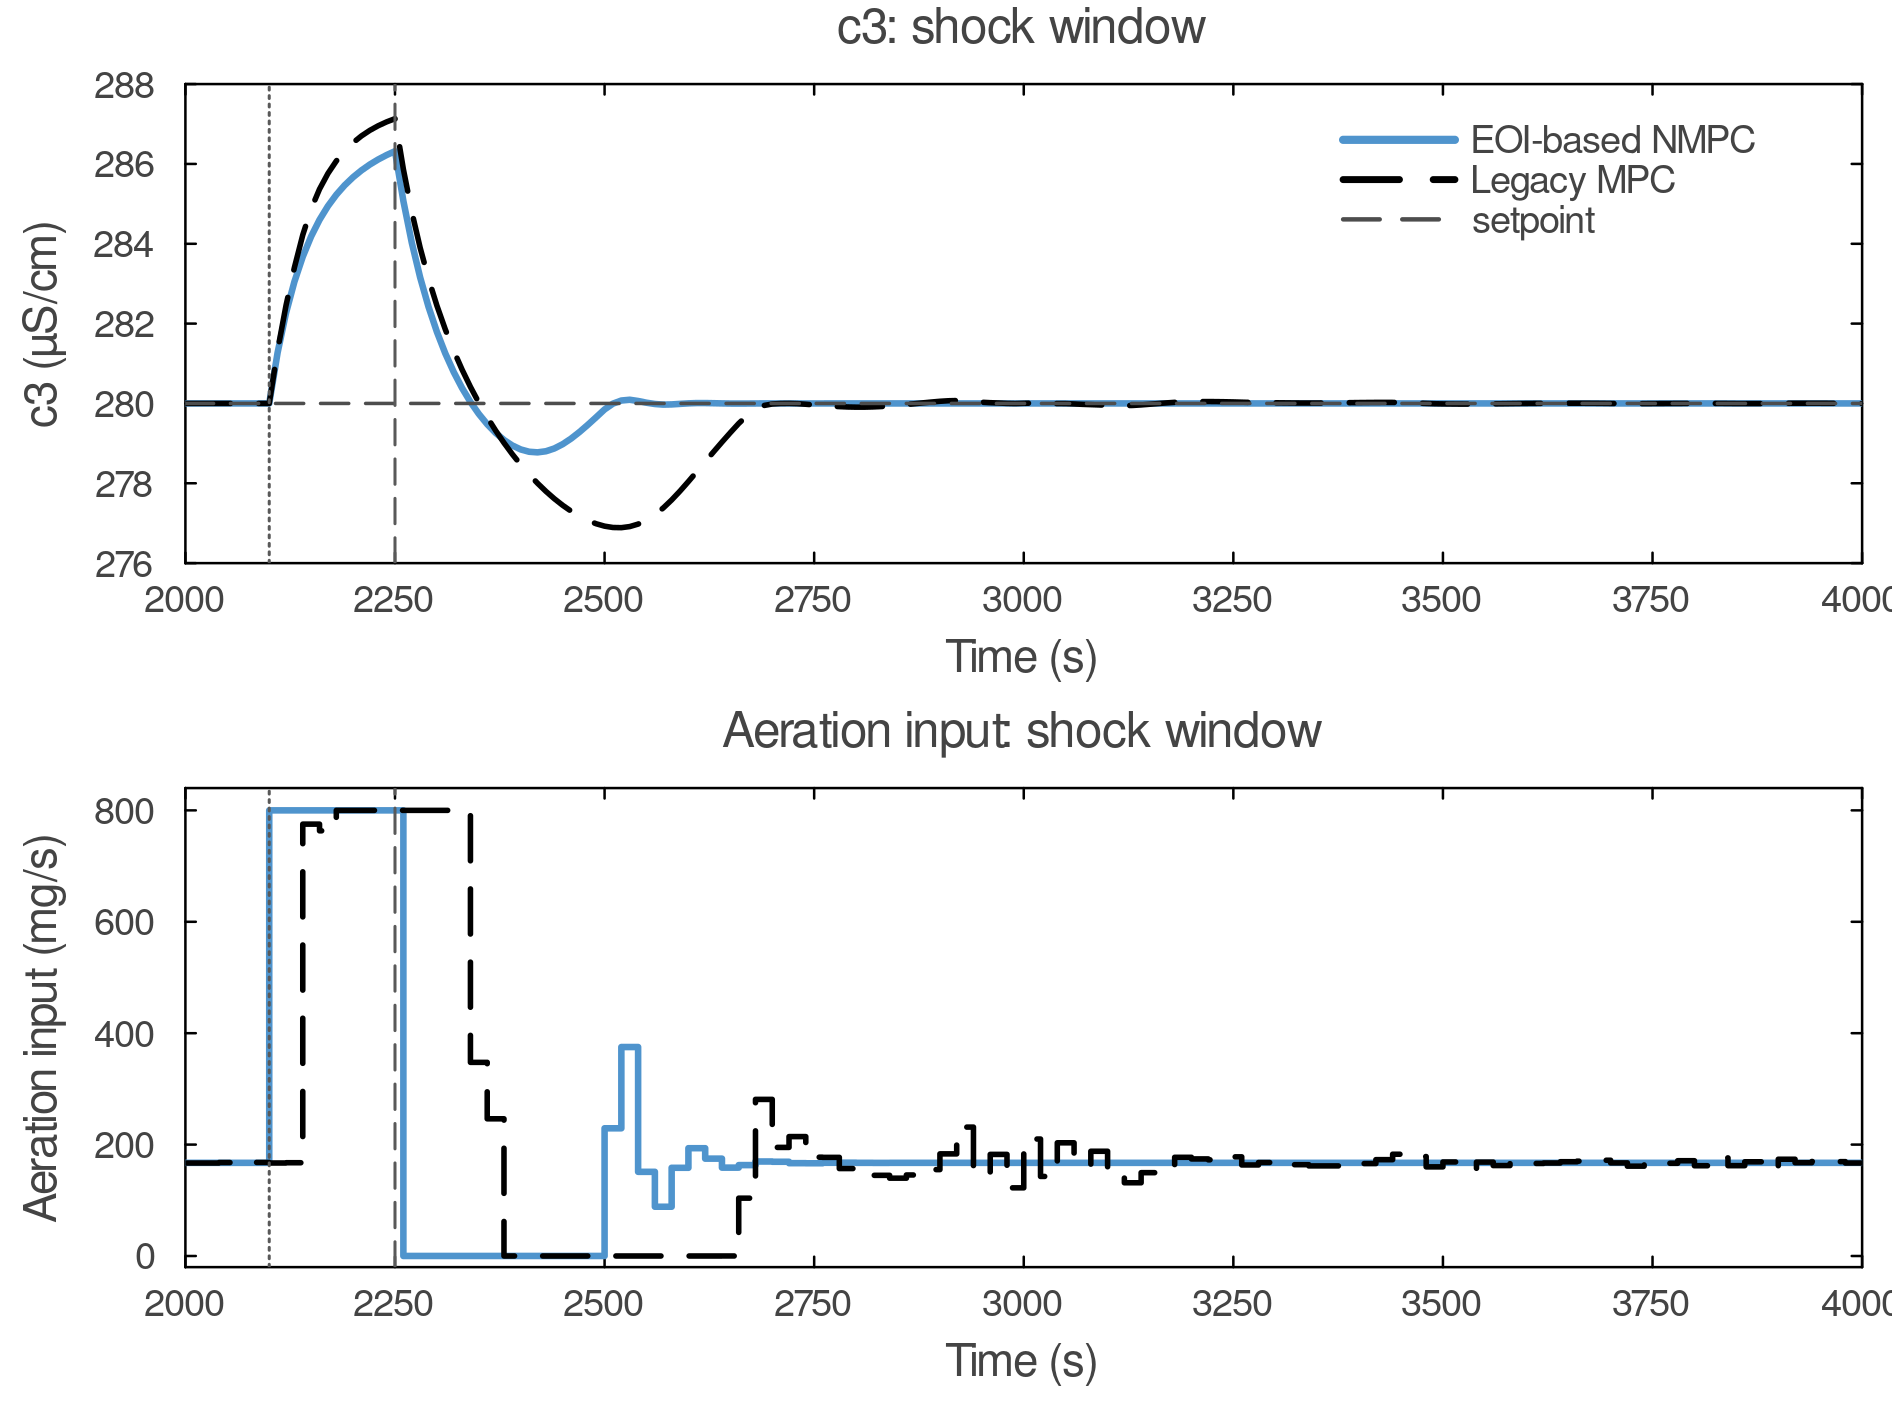

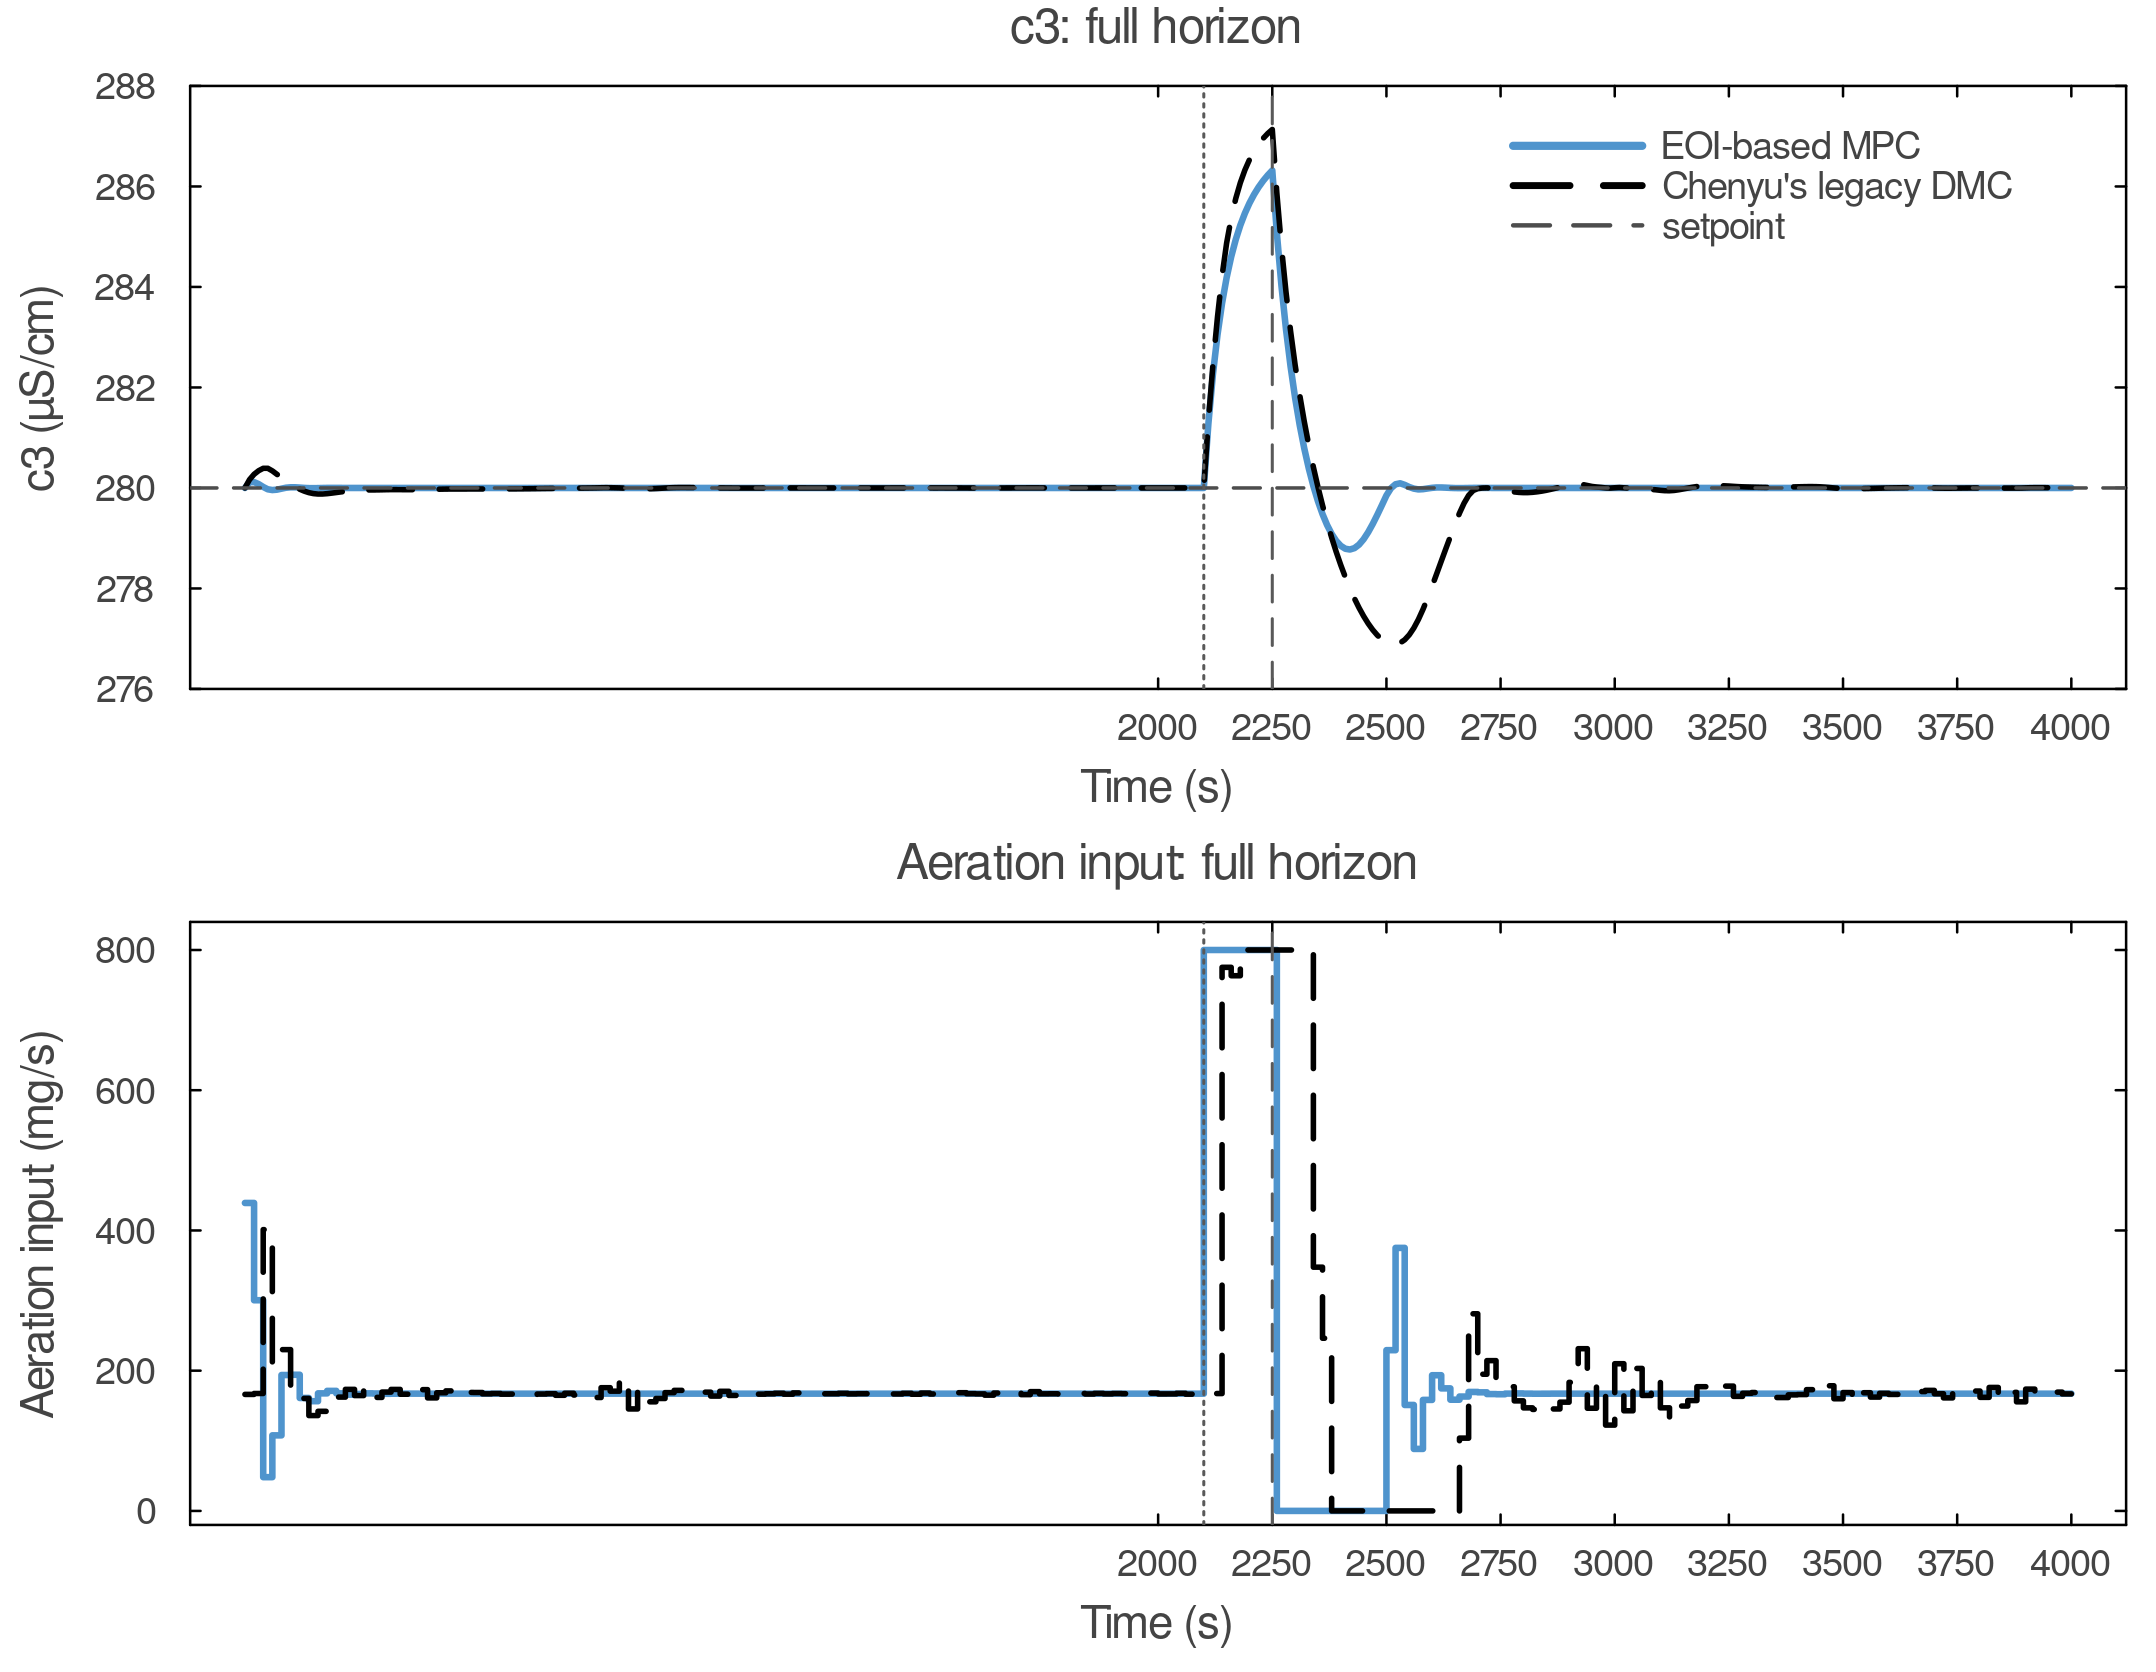

In [12]:
legacy_closed_loop = CSV.read(legacy_path, DataFrame)

shock_window = NDMC_PLOT_CONFIG.shock_window
disturbance_window = NDMC_PLOT_CONFIG.disturbance_window

paper_pair = ndmc_plot_shock_window_pair(
    closed_loop,
    legacy_closed_loop;
    tspan = shock_window,
    disturbance_window = disturbance_window,
)
full_pair = ndmc_plot_legacy_comparison_pair(
    closed_loop,
    legacy_closed_loop;
    disturbance_window = disturbance_window,
    title_suffix = "full horizon",
)

display(paper_pair)
full_pair


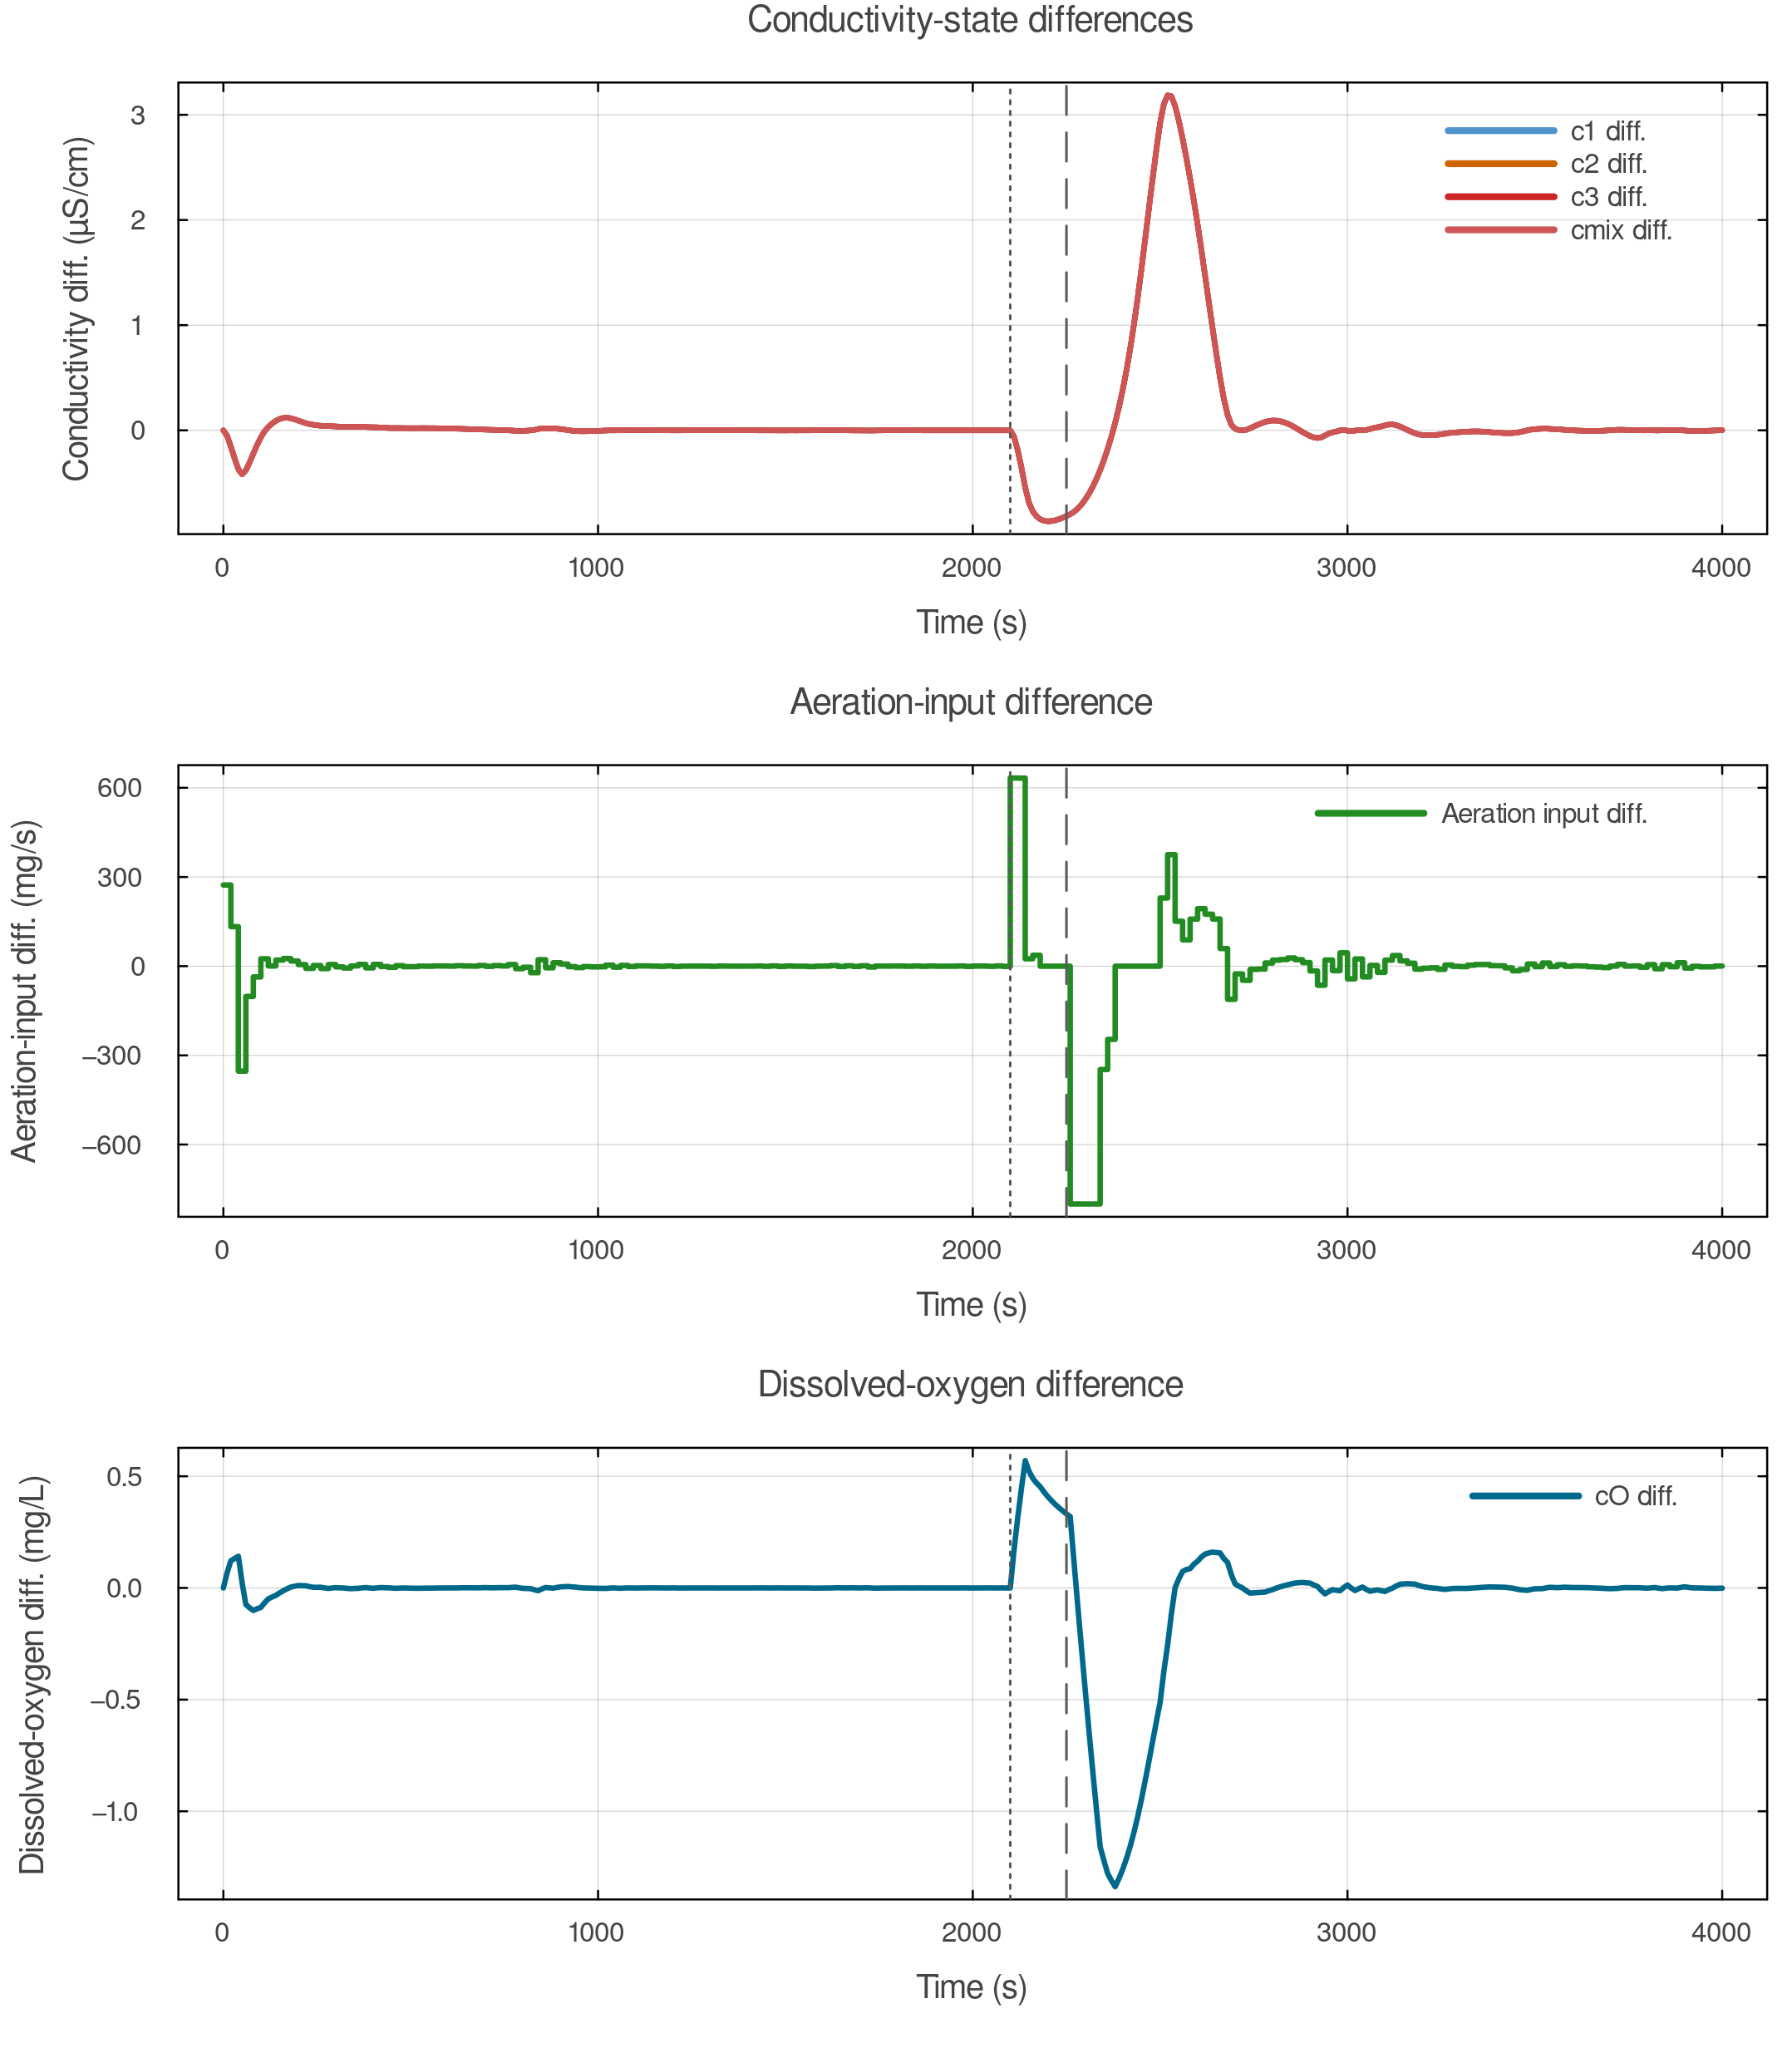

In [13]:
comparison_df = CSV.read(comparison_path, DataFrame)
ndmc_plot_difference_pair(comparison_df; disturbance_window = NDMC_PLOT_CONFIG.disturbance_window)
